# Take Redstone Data and Measure Throughput and FSR and Finesse


In [28]:
# load etalon redstone data
import numpy as np
import matplotlib.pylab as plt
import scipy
from pandas import read_csv

# load osa data
def load_osa(filename='osa_data/hirax_607filter_hot_take2.csv',vmin=0,vmax=5000):
    out = read_csv(filename,skiprows=147,names=['x','y'],sep=';',skipfooter=1,engine='python')

    w_out = out['x'].values
    s_out = out['y'].values
  
    isub = np.where((w_out>vmin) & (w_out < vmax))[0]

    return w_out[isub], s_out[isub]


In [25]:
# Load files
v_et,f_et = load_osa(filename='20250717_FTOfibers_1300nmSLD_blueetalon.csv',vmin=1200,vmax=1400)
v_no,f_no = load_osa(filename='20250717_FTOfibers_1300nmSLD_noetalon.csv',vmin=1200,vmax=1400)



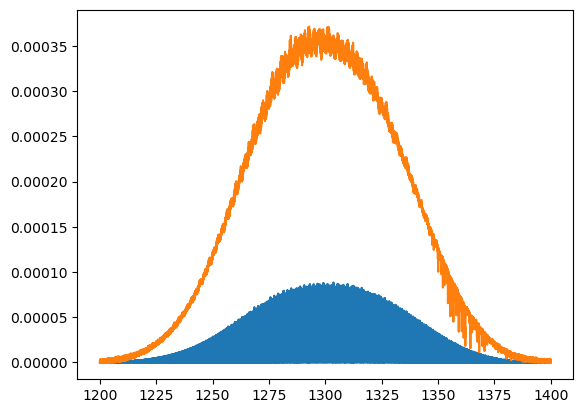

In [26]:
plt.plot(v_et, f_et)
plt.plot(v_no,f_no)


## Throughput

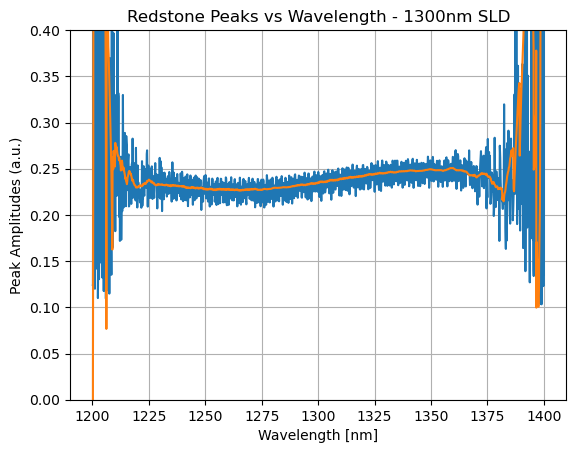

In [174]:
throughput = f_et/f_no

# peak finder
peaks = scipy.signal.find_peaks(throughput,distance=5,prominence=0.1)

#plt.plot(v_et,throughput)
plt.plot(v_et[peaks[0]],throughput[peaks[0]])
plt.ylim(0,0.4)
#plt.xlim(1225,1226)

# Smooth throughput of peaks
ydata_smooth = scipy.signal.savgol_filter(throughput[peaks[0]],60,3) 
plt.plot(v_et[peaks[0]],ydata_smooth)
plt.grid()
plt.ylabel('Peak Amplitudes (a.u.)')
plt.xlabel('Wavelength [nm]')
plt.title('Redstone Peaks vs Wavelength - 1300nm SLD')
plt.savefig('result_throughputuniformity_1300nm.png')

# Finesse and FSR

[2.61107762e-05 1.24791766e+03 9.57274851e-03]
-30.31847706451706
0.17045458757763965
18.803377087692887
0.009572748510043597
130000.0


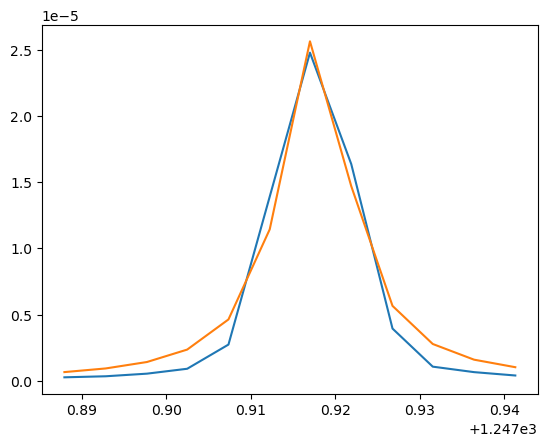

In [110]:
from astropy.modeling.functional_models import Lorentz1D
# normalize and find peaks
normalized = f_et/np.max(f_et)
peaks = scipy.signal.find_peaks(normalized,distance=5,prominence=0.1)

# quick plot to see
ipeak = peaks[0][100]
span = 6
xtemp, ytemp = v_et[ipeak-span:ipeak+span], f_et[ipeak-span:ipeak+span]
plt.plot(xtemp, ytemp)

# Fit peak with Lorentzians
def lorentz(x,amplitude, x0, fwhm):
    test = Lorentz1D(amplitude=amplitude,x_0=x0,fwhm=fwhm)
    return test(x)

best_fit = scipy.optimize.curve_fit(lorentz, xtemp,ytemp,p0=(2.5e-5,np.mean(xtemp),0.025))
params = best_fit[0]

plt.plot(xtemp,lorentz(xtemp, *params))

print(params)

fwhm = params[-1] # in nm
FSR = np.mean(np.diff(3e8/v_et[peaks[0]]))
print(FSR)
print(np.mean(np.diff(v_et[peaks[0]])))

finesse = 0.18/fwhm
print(finesse)

print(fwhm)
print(1300/0.01)

We measure the FSR to be 30.3 GHz and the finesse to be around 18. This is a FWHM of 0.01, which is close to the resolution of the instrument. The scans with the laser should be more telling

# Laser Sweep Measurements
"Hey folks, here are the .txt files containing the etalon and reference laser scan at 1028 nm. The wavelength-vs-drive-current relationship should be extremely linear per the vendor, so we should be able to convert to wavelength pretty easily. For 1028 nm, I measured that the wavelength at 37.6 mA (~10% into the scan range) was 1027.5628653 nm, and the wavelength at 222.0 mA (~90% into the scan range) was 1027.9226506 nm as of this morning. Hopefully the laser didn't drift too much, since we're convolving the drift of the etalon and the laser! " -Greg

In [165]:
# Load csv files from Greg
las_1028_etalon = np.loadtxt('Sweeps_Etalon_1028.txt',skiprows=1).T
las_1028_ref    = np.loadtxt('Sweeps_Ref_1028.txt',skiprows=1).T

# wavelength current conversion from Greg's note
amps = [37.6, 222.0]
waves = [1027.5628653, 1027.9226506]
def wave_fxn(current): 
    # quick y-y0 = slope *(x-x0)
    slope = np.diff(waves)/np.diff(amps)
    return waves[0] + slope * (current - amps[0])


## Throughput

[0.10009211 0.10477479 0.10126278]


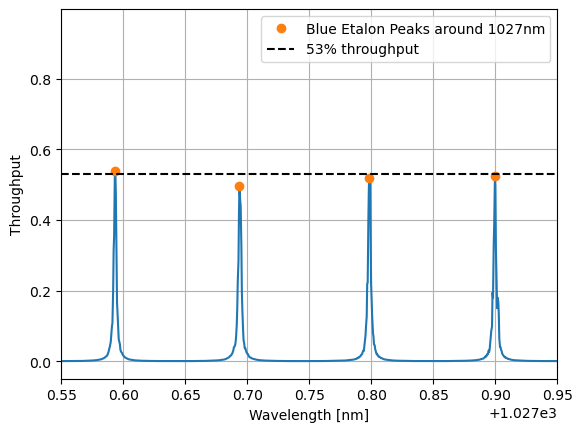

In [166]:
# Plot, confirmed that x sampling (current) is same between files
plt.plot(wave_fxn(las_1028_ref[0]), las_1028_etalon[1]/las_1028_ref[1])
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('Throughput')
plt.xlim(1027.55, 1027.95)

wavelength = wave_fxn(las_1028_ref[0])
throughput =  las_1028_etalon[1]/las_1028_ref[1]
peaks      = scipy.signal.find_peaks(throughput,distance=5,prominence=0.1)

plt.plot(wavelength[peaks[0]], throughput[peaks[0]],'o',label='Blue Etalon Peaks around 1027nm')
plt.axhline(0.53,c='k',ls='--',label='53% throughput')
plt.legend()
print(np.diff(wavelength[peaks[0]]))
plt.savefig('result_throughput_1028nm_blueetalon.png')

The throughput is about 50% for these wavelengths

## Finesse

fwhm(nm): -0.002642711951908882
FSR nm: 0.1020432277114196
FSR (GHz): -28.982335914450232
finesse: 38.613072316758476


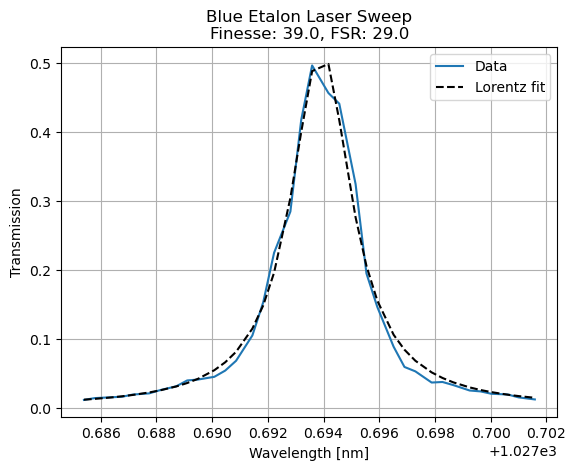

In [167]:
wavelength = wave_fxn(las_1028_ref[0])
throughput = las_1028_etalon[1]/las_1028_ref[1]
peaks      = scipy.signal.find_peaks(throughput,distance=5,prominence=0.1)

# quick plot to see what we're fitting
ipeak = peaks[0][1]
span = 18
xtemp, ytemp = wavelength[ipeak-span:ipeak+span], throughput[ipeak-span:ipeak+span]
plt.plot(xtemp, ytemp,label='Data')

# Fit peak with Lorentzians
# define fit fxn in curve_fit format
def lorentz(x,amplitude, x0, fwhm):
    test = Lorentz1D(amplitude=amplitude,x_0=x0,fwhm=fwhm)
    return test(x)
# do the fit
best_fit = scipy.optimize.curve_fit(lorentz, xtemp,ytemp,p0=(0.55,np.mean(xtemp),0.025))
params = best_fit[0]

# plot the fit and label things
plt.plot(xtemp,lorentz(xtemp, *params),'k--',label='Lorentz fit')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Transmission')
plt.grid()

plt.legend()

# calculate fsr and finesse
fwhm = params[-1] # in nm
print('fwhm(nm):', fwhm)
FSR_nm = np.mean(np.diff(wavelength[peaks[0]]))
print('FSR nm:',FSR_nm)
FSR = np.mean(np.diff(3e8/wavelength[peaks[0]]))
print('FSR (GHz):', FSR)

finesse = np.abs(FSR_nm/fwhm)
print('finesse:',finesse)
plt.title("Blue Etalon Laser Sweep\nFinesse: %s, FSR: %s"%(np.round(finesse), np.round(np.abs(FSR))))
plt.savefig('result_finesse_blueetalon_1028nm.png')

*Discussion* : In the 1028nm dataset, the FSR makes sense and seems consistent indicating that the laser likely didn't drift much and the wavelength conversion is sensible. The finesse is close to the vendor's of 39.5 at 1064nm. The FSR is close to the spec of 30GHz. The transmission is meeting spec although it is a little lower than the vendor's measurement of 58.4% at 1064nm. This may be due to the fact that we have one less fiber connection when measureing the reference spectrum. These connections can cause losses of 5-20% according to Nem so can explain the difference. 

# 1270 nm Data


In [168]:
# Load csv files from Greg
las_1270_etalon = np.loadtxt('Sweeps_Etalon_1270.txt',skiprows=1).T
las_1270_ref    = np.loadtxt('Sweeps_Ref_1270.txt',skiprows=1).T

# wavelength current conversion from Greg's note
amps = [13.7, 59.3]
waves = [1270.1408350, 1270.5759997]

In [169]:
wavelength = wave_fxn(las_1270_ref[0])
throughput =  las_1270_etalon[1]/las_1270_ref[1]
peaks      = scipy.signal.find_peaks(throughput,distance=5,prominence=0.1)


[0.15364368 0.12692304 0.06012144]


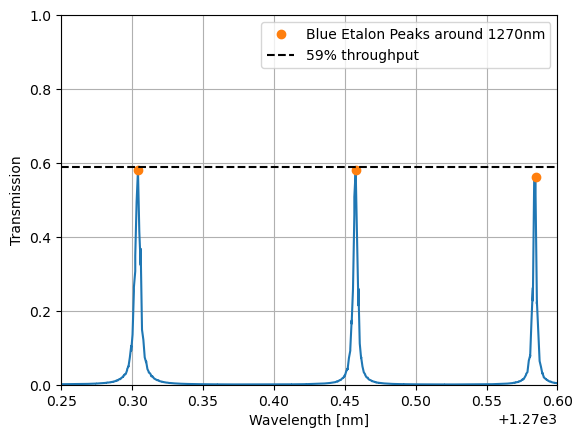

In [170]:
plt.plot(wavelength, throughput)
plt.plot(wavelength[peaks[0]], throughput[peaks[0]],'o',label='Blue Etalon Peaks around 1270nm')
plt.ylim(0,1)
plt.xlim(1270.25,1270.6)
print(np.diff(wavelength[peaks[0]]))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Transmission')
plt.axhline(0.59,c='k',ls='--',label='59% throughput')
plt.legend()
plt.grid()
plt.savefig('result_throughput_1270nm_blueetalon.png')

fwhm(nm): 0.003237191502066964
FSR nm: 0.11356271776314013
FSR (GHz): -21.106937609283097
finesse: 35.08063013591557


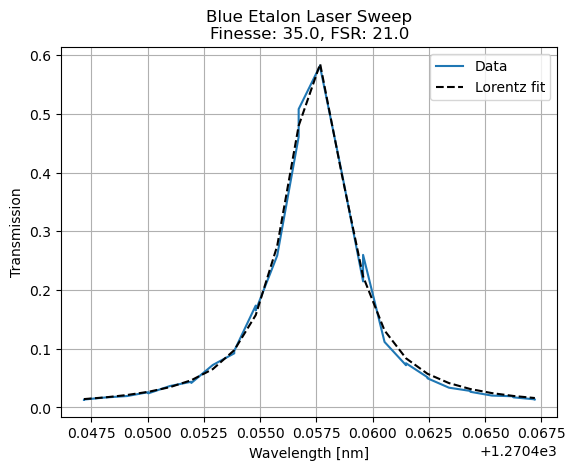

In [171]:
# quick plot to see what we're fitting
ipeak = peaks[0][1]
span = 18
xtemp, ytemp = wavelength[ipeak-span:ipeak+span], throughput[ipeak-span:ipeak+span]
plt.plot(xtemp, ytemp,label='Data')

# Fit peak with Lorentzians
# do the fit
best_fit = scipy.optimize.curve_fit(lorentz, xtemp,ytemp,p0=(0.55,np.mean(xtemp),0.025))
params = best_fit[0]

# plot the fit and label things
plt.plot(xtemp,lorentz(xtemp, *params),'k--',label='Lorentz fit')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Transmission')
plt.grid()

plt.legend()

# calculate fsr and finesse
fwhm = params[-1] # in nm
print('fwhm(nm):', fwhm)
FSR_nm = np.mean(np.diff(wavelength[peaks[0]]))
print('FSR nm:',FSR_nm)
FSR = np.mean(np.diff(3e8/wavelength[peaks[0]]))
print('FSR (GHz):', FSR)

finesse = np.abs(FSR_nm/fwhm)
print('finesse:',finesse)
plt.title("Blue Etalon Laser Sweep\nFinesse: %s, FSR: %s"%(np.round(finesse), np.round(np.abs(FSR))))
plt.savefig('result_finesse_blueetalon_1270nm.png')

*Discussion:* Can't trust this data because the FSR doesn't make sense. It is likely that either the laser drifted or the power sweep to wavelength conversion isn't actually linear. Will double check the latter and re-run the data as needed. 

Overall though the vendor sees a throughput of 58.4% at 1064nm and 65% at 1348nm. We see a throughput of ~50% at 1um and ~57% at 1.27um. We have an extra fiber connection in our reference spectrum which may be the cause of the lower throughput, but it is good we see consistency in the increase of the throughput at the same wavelegnths.